In [2]:
import sys
import os
import numpy as np

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

from src.channel import *
from src.grouping import *

# Generate channels
h_BI, h_IU = generate_channels(1000)

# Cascaded channel
cascaded = h_BI * h_IU

# SBL grouping
groups = sbl_grouping(
    cascaded,
    Q=250
)

# Effective channel
h_eff = grouped_channel(
    h_BI,
    h_IU,
    groups
)

print("Effective Channel =", h_eff)
print("Channel Gain =", abs(h_eff)**2)

Effective Channel = (782.242194965143+8.897396708285044e-15j)
Channel Gain = 611902.8515838848


In [3]:
random_groups = random_grouping(
    len(cascaded),
    250
)

adjacent_groups = adjacent_grouping(
    len(cascaded),
    250
)

phase_groups = phase_grouping(
    cascaded,
    250
)

hybrid_groups = hybrid_grouping(
    cascaded,
    250
)
h_random = grouped_channel(
    h_BI,
    h_IU,
    random_groups
)

h_adjacent = grouped_channel(
    h_BI,
    h_IU,
    adjacent_groups
)

h_phase = grouped_channel(
    h_BI,
    h_IU,
    phase_groups
)

h_sbl = grouped_channel(
    h_BI,
    h_IU,
    groups
)

h_hybrid = grouped_channel(
    h_BI,
    h_IU,
    hybrid_groups
)
print("Random :", abs(h_random)**2)
print("Adjacent :", abs(h_adjacent)**2)
print("Phase :", abs(h_phase)**2)
print("SBL :", abs(h_sbl)**2)
print("Hybrid :", abs(h_hybrid)**2)

Random : 166831.59726653434
Adjacent : 180619.25818828255
Phase : 611895.935318193
SBL : 611902.8515838848
Hybrid : 606613.5427104154


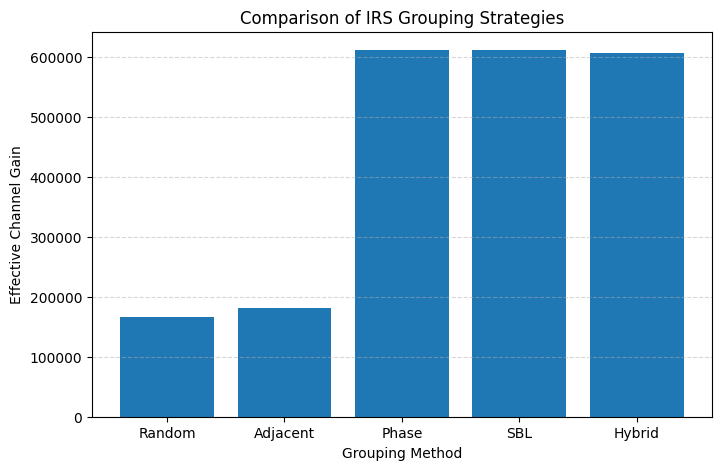

In [4]:
import matplotlib.pyplot as plt

methods = [
    "Random",
    "Adjacent",
    "Phase",
    "SBL",
    "Hybrid"
]

gains = [
    166831.59726653434,
    180619.25818828255,
    611895.935318193,
    611902.8515838848,
    606613.5427104154
]

plt.figure(figsize=(8,5))

plt.bar(
    methods,
    gains
)

plt.ylabel("Effective Channel Gain")
plt.xlabel("Grouping Method")
plt.title("Comparison of IRS Grouping Strategies")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.savefig(
    "../results/figures/grouping_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()